# Grayscale vs. Color Images

As discussed in the previous Notebook, Grayscale images are two-dimensional matrices (`rows x columns`). We can read and write pixel values by specifiying the matrix index.

Color images in contrast are three-dimensional matrices. The third dimension is also referred to as channel(s). Therefor a color image is specified by `row(s) x column(s) x channel(s)`. 

Most color images are represented by 3 channels, namely Red, Green and Blue (RGB).  
Each single channel can be thought of as a grayscale image denoting the intensity of the corresponding color channel. ("How green/red/blue is object A?")

Let us open an RGB image and visualise the single channels:

## Visualising RGB images

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Utility functions - only used for GUI features
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


%matplotlib inline

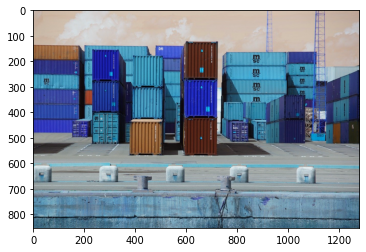

In [2]:
# Read in the image
image = cv2.imread('images/container.jpg')

plt.imshow(image)

Hmmm... something looks odd here? 

By default OpenCV loads color images in BGR channel sequence, meaning the blue channel comes first, green channel second and red channel third. 
In contrast `plt.imshow()` expects color images in RGB channel sequence. Therefor, before visualising an image, we need to swap the blue and red channel. This can be done using `cv2.cvtColor()` and specifying the conversion.



Therefor the "R"ed and "B"lue channel 

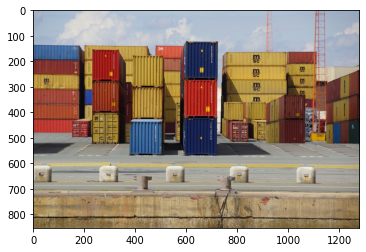

In [3]:
# Convert the image
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)

After loading the image, we will now extract each channel from the rgb image and visualise them as intensity images. Each pixel corresponds to the intensity of the corresponding color channel.

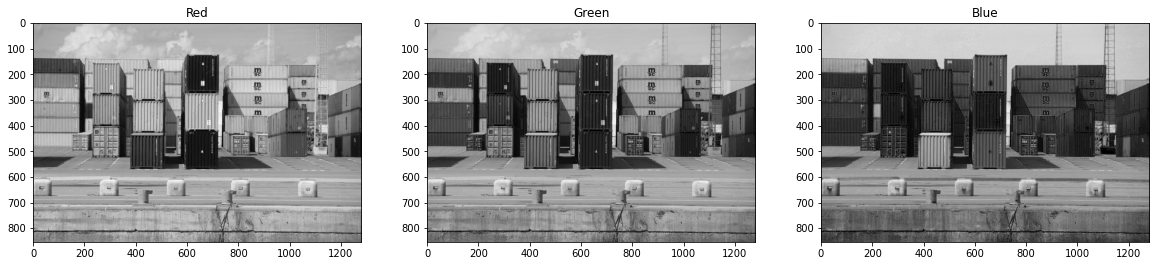

In [4]:
# RGB channels
r = rgb[:,:,0]
g = rgb[:,:,1]
b = rgb[:,:,2]

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))

ax1.set_title('Red')
ax1.imshow(r, cmap='gray')

ax2.set_title('Green')
ax2.imshow(g, cmap='gray')

ax3.set_title('Blue')
ax3.imshow(b, cmap='gray')


Lets display this using colors now by replacing two of the three channels values with zeros:

Each pixel value corresponds to the intensity of the color channel. White corresponds to high and black to low intensity of the corresponding color.

This allows us to consider RGB color images as a composition of three grayscale matrices. Let's try to extend our grayscale functions to also work on RGB images.

If we want to visualise a color channel in its true color, we can do so by removing the other color spaces. An example can be found below:

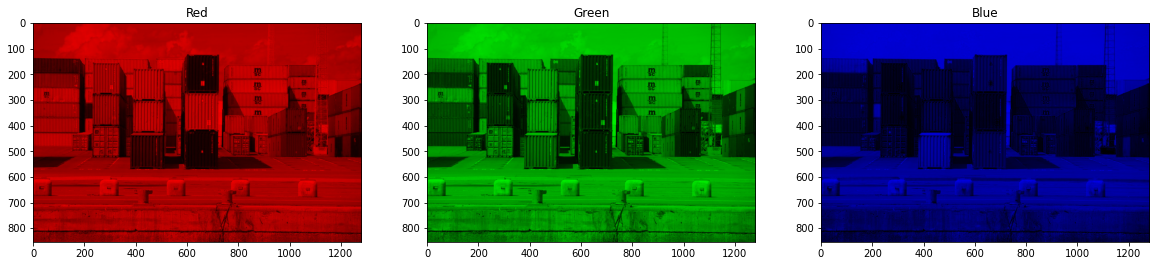

In [5]:
# Channels
RED = 0
GREEN = 1
BLUE = 2

# Red image: RGB image with intensity value of 0 in green and blue channel
r = rgb.copy()
r[:,:,GREEN] = 0
r[:,:,BLUE] = 0

# Red image: RGB image with intensity value of 0 in red and blue channel
g = rgb.copy()
g[:,:,RED] = 0
g[:,:,BLUE] = 0

# Red image: RGB image with intensity value of 0 in green and red channel
b = rgb.copy()
b[:,:,GREEN] = 0
b[:,:,RED] = 0

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))

ax1.set_title('Red')
ax1.imshow(r)

ax2.set_title('Green')
ax2.imshow(g)

ax3.set_title('Blue')
ax3.imshow(b)

# Exercise 3: Adjustment color
Similar to changing the intensity of a pixels value, we can now change the intensity of the red, green and blue channel in our images using the same setup. Finish the code snippet below to change the intensity of the color channels.

Note the input to the function: 
- `channel`: Specifies the target channel (red, green or blue) to be adjusted, either 0, 1 or 2.
- `x`: Specifies the multiplicative value to be applied. Range: 0.8 - 1.2
       

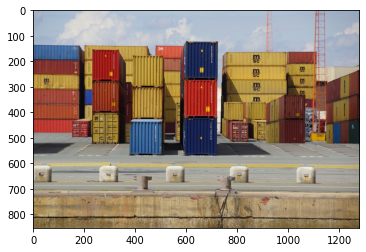

In [6]:
def adjust_color(x, channel):
    """
    Adjust the color of our image by adjusting the intensity values of the selected channel.
    
    x: Specifies the multiplicative value to be applied to selected channel.
    channel: Specifies the channel to be selected.
    """
    adjusted_im = rgb.copy()
    
    #TODO: Adjust the channel 'channel' by multiplying it with 'x'
    
    plt.imshow(adjusted_im, vmin=0, vmax=255)               

# This function helps to interactively visualise our image. 
interact(adjust_color, x=(0.8, 1.2, 0.05), channel=(0,2,1));

## Lösung

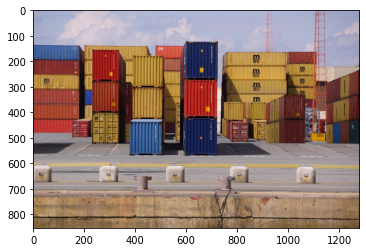

In [7]:
def adjust_color(x, channel):
    """
    Adjust the color of our image by adjusting the intensity values of the selected channel.
    
    x: Specifies the multiplicative value to be applied to selected channel.
    channel: Specifies the channel to be selected.
    """
    adjusted_im = rgb.copy()
    
    #TODO: Adjust the channel 'channel' by multiplying it with 'x'
    adjusted_im[:, :, channel] = adjusted_im[:, :, channel] * x
    
    plt.imshow(adjusted_im, vmin=0, vmax=255)               

# This function helps to interactively visualise our image. 
interact(adjust_color, x=(0.8, 1.2, 0.05), channel=(0,2,1));

# Excercise 4: Color Segmentation

Similar to our grayscale segmentation problem, we can now segment out single colors. 
Try to adjust the code below to segment out the light blue, off-centered container. What are the threshold levels fpr each channel?

Note the input to the function: 
- `r_min`: Specifies the lower level threshold for the red channel.
- `r_max`: Specifies the upper level threshold for the red channel.
- `g_min`: Specifies the lower level threshold for the green channel.
- `g_max`: Specifies the upper level threshold for the green channel.
- `b_min`: Specifies the lower level threshold for the blue channel.
- `b_max`: Specifies the upper level threshold for the blue channel.

NameError: name 'mask_rgb' is not defined

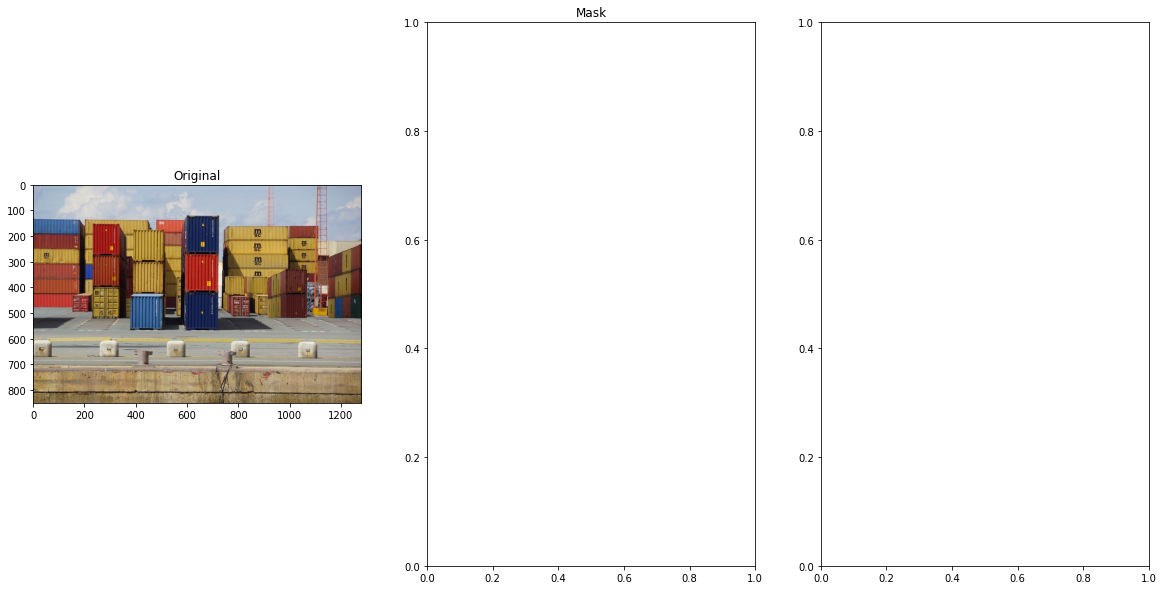

In [8]:
def rgb_color_masking(r_min=180, r_max=255, g_min=0, g_max=255, b_min=100, b_max=230):
    # Define our color selection criteria in RGB values
    lower_color = np.array([r_min, g_min, b_min]) 
    upper_color = np.array([r_max, g_max, b_max])

    # TODO: Define the masked area in RGB space
    
    # TODO: Mask the image
    
    # Vizualize the mask
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))

    ax1.set_title('Original')
    ax1.imshow(rgb)

    ax2.set_title('Mask')
    ax2.imshow(mask_rgb, cmap='gray')

    ax3.set_title('Masked Image')
    ax3.imshow(masked_image)
    
interact(rgb_color_masking, 
         r_min=(0, 255), r_max=(0, 255), 
         g_min=(0, 255), g_max=(0, 255), 
         b_min=(0, 255), b_max=(0, 255));

## Lösung

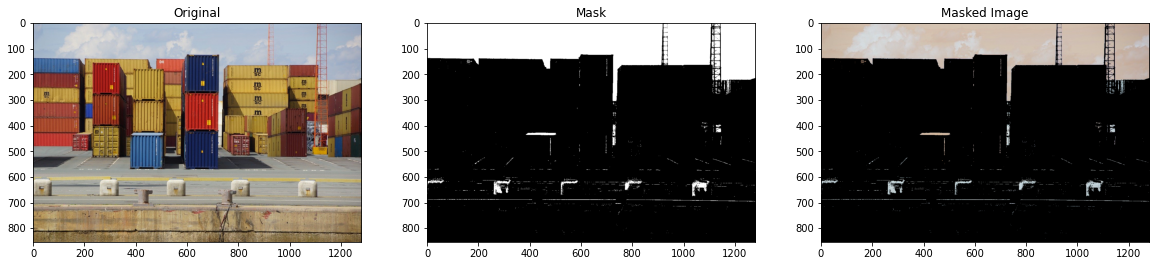

In [9]:
# Lösung
def rgb_color_masking(r_min=180, r_max=255, g_min=0, g_max=255, b_min=100, b_max=230):
    # Define our color selection criteria in RGB values
    lower_color = np.array([r_min, g_min, b_min]) 
    upper_color = np.array([r_max, g_max, b_max])

    # Define the masked area in RGB space
    mask_rgb = cv2.inRange(image, lower_color, upper_color)

    # mask the image
    masked_image = np.copy(image)
    masked_image[mask_rgb==0] = [0,0,0]

    # Vizualize the mask
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))

    ax1.set_title('Original')
    ax1.imshow(rgb)

    ax2.set_title('Mask')
    ax2.imshow(mask_rgb, cmap='gray')

    ax3.set_title('Masked Image')
    ax3.imshow(masked_image)
    
interact(rgb_color_masking, 
         r_min=(0, 255), r_max=(0, 255), 
         g_min=(0, 255), g_max=(0, 255), 
         b_min=(0, 255), b_max=(0, 255));


Values to segment out the light blue, off-centered container: 
- `r_min`:   69
- `r_max`:   167
- `g_min`:   70
- `g_max`:   127
- `b_min`:   0
- `b_max`:   80

# Color Spaces

As discussed in the theory part of this module, there are different methods of representing color. 

In the following chapter we will have a look at another 3-channel colorspace called HSV. Similar to the RGB color space, it consists of three channels, corresponding to Hue, Saturation and Value.

Below, you can switch in between the spaces. What has changed? Discuss the results. 

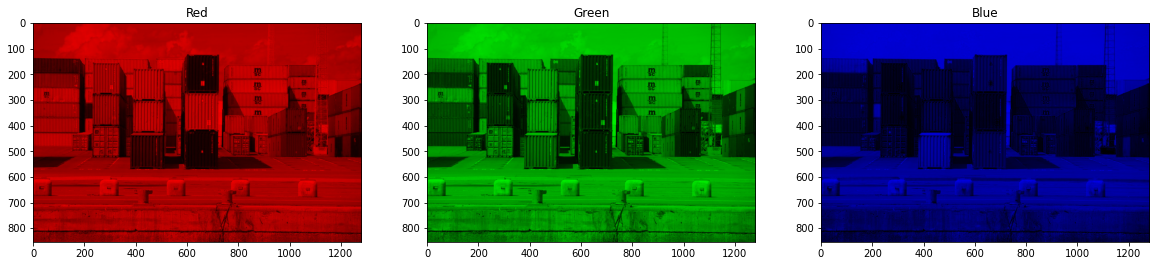

In [10]:
def interactive_colorspaces(x):
    image = cv2.imread('images/container.jpg')
    colorspaces = [cv2.COLOR_BGR2RGB, cv2.COLOR_BGR2HSV]
    # Convert image to color space
    cvted_image = cv2.cvtColor(image, colorspaces[x])
    # Split the hxwxc matrix into 3 hxw matrices
    channel_1 = cvted_image[:,:,0]
    channel_2 = cvted_image[:,:,1]
    channel_3 = cvted_image[:,:,2]
    
    # Plot the images
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))
    
    # RGB
    if x == 0: # RGB
        # Red image: RGB image with intensity value of 0 in Green and Blue channel
        r = cvted_image.copy()
        r[:,:,GREEN] = 0
        r[:,:,BLUE] = 0

        # Red image: RGB image with intensity value of 0 in Green and Blue channel
        g = cvted_image.copy()
        g[:,:,RED] = 0
        g[:,:,BLUE] = 0

        # Red image: RGB image with intensity value of 0 in Green and Blue channel
        b = cvted_image.copy()
        b[:,:,GREEN] = 0
        b[:,:,RED] = 0
        ax1.set_title('Red')
        ax1.imshow(r)
        ax2.set_title('Green')
        ax2.imshow(g)
        ax3.set_title('Blue')
        ax3.imshow(b)
    # HSV
    else: 
        ax1.set_title('Hue')
        ax1.imshow(channel_1, cmap='hsv')
        ax2.set_title('Saturation')
        ax2.imshow(channel_2, cmap='gray')
        ax3.set_title('Value')
        ax3.imshow(channel_3, cmap='gray')
    
interact(interactive_colorspaces, 
         x=(0,1));

# Optional Exercise - Greenscreen
Especially in the film industry, on television and on YouTube, this simple method is still used today in the form of the "green screen". Try to replace the greenscreen in a picture with a background of your choice. For this we segment the object using the functions from our first Jupyter notebook. Afterwards you can insert a background of your choice.

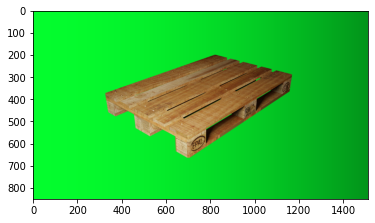

In [11]:
# Read in the image
image = cv2.imread('images/greenscreen.png')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

### Lösung

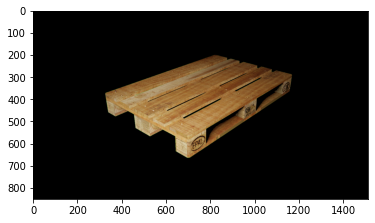

In [12]:
image = cv2.imread('images/greenscreen.png')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Change to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Define our color selection boundaries in HSV values
# This initial threshold allows a certain low range for Hue (H)
lower_hue = np.array([0,0,0]) 
upper_hue = np.array([50,255,255])

# Define the masked area
mask = cv2.inRange(image, lower_hue, upper_hue)

# Mask the image to let the pallet show through
masked_image = np.copy(image)
masked_image[mask != 0] = [0, 0, 0]

# Display it!
plt.imshow(masked_image)